# FusionGP: Multi-Source NO₂ Fusion Demo

This notebook demonstrates the complete workflow for using FusionGP to fuse
heterogeneous air quality observations (EPA, low-cost sensors, satellite)
into a unified spatio-temporal field with uncertainty quantification.

## Contents
1. Data Loading and Preprocessing
2. Model Configuration
3. Training
4. Prediction and Inference
5. Evaluation
6. Visualization

In [ ]:
# Install dependencies if needed
# !pip install torch gpytorch pandas numpy scipy scikit-learn matplotlib seaborn tqdm pyyaml

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.9.1+cu128
Device: cpu


## 1. Generate Synthetic Data

For this demo, we'll create synthetic data mimicking the structure of real
multi-source NO₂ observations. In practice, you would load your actual data.

In [2]:
# def generate_synthetic_data(n_grid=100, n_times=30, seed=42):
#     """
#     Generate synthetic multi-source NO₂ data.
    
#     Parameters
#     ----------
#     n_grid : int
#         Number of grid cells (10x10 = 100 for 10km domain with 100m resolution subset)
#     n_times : int
#         Number of daily timestamps
#     """
#     np.random.seed(seed)
    
#     # Create spatial grid (~10km x 10km urban area)
#     lat_range = (40.70, 40.80)  # NYC-like coordinates
#     lon_range = (-74.05, -73.95)
    
#     n_lat = int(np.sqrt(n_grid))
#     n_lon = int(np.sqrt(n_grid))
    
#     lats = np.linspace(lat_range[0], lat_range[1], n_lat)
#     lons = np.linspace(lon_range[0], lon_range[1], n_lon)
    
#     # Create timestamps (daily)
#     dates = pd.date_range('2024-01-01', periods=n_times, freq='D')
    
#     # Create full grid
#     records = []
#     grid_id = 0
    
#     for i, lat in enumerate(lats):
#         for j, lon in enumerate(lons):
#             for t, date in enumerate(dates):
#                 # True latent NO2 field (smooth spatial + temporal pattern)
#                 spatial_pattern = 20 + 10 * np.sin(2*np.pi*(lat - lat_range[0])/(lat_range[1]-lat_range[0]))
#                 temporal_pattern = 5 * np.sin(2*np.pi*t/7)  # Weekly cycle
#                 true_no2 = spatial_pattern + temporal_pattern + np.random.randn() * 2
                
#                 record = {
#                     'grid_id': i * n_lon + j,
#                     'latitude': lat,
#                     'longitude': lon,
#                     'timestamp': date,
#                     'true_no2': true_no2,  # Ground truth (not available in practice)
#                 }
                
#                 # EPA observations (sparse, low noise)
#                 if np.random.rand() < 0.05:  # 5% coverage
#                     record['epa_no2'] = true_no2 + np.random.randn() * 1.0
#                 else:
#                     record['epa_no2'] = np.nan
                
#                 # Low-cost sensor observations (dense, biased, higher noise)
#                 if np.random.rand() < 0.7:  # 70% coverage
#                     # Bias: y = 1.2 * f + 3 + noise
#                     record['low_cost_data'] = 1.2 * true_no2 + 3 + np.random.randn() * 4.0
#                 else:
#                     record['low_cost_data'] = np.nan
                
#                 # Satellite observations (moderate coverage, moderate noise)
#                 if np.random.rand() < 0.4:  # 40% coverage (cloud gaps)
#                     record['satellite_values'] = true_no2 + np.random.randn() * 3.0
#                 else:
#                     record['satellite_values'] = np.nan
                
#                 records.append(record)
    
#     df = pd.DataFrame(records)
#     return df

# # Generate data
# df = generate_synthetic_data(n_grid=100, n_times=30)
# print(f"Generated {len(df):,} records")
# print(f"\nData shape: {df.shape}")
# print(f"\nColumn info:")
# for col in ['epa_no2', 'low_cost_data', 'satellite_values']:
#     n_valid = df[col].notna().sum()
#     print(f"  {col}: {n_valid:,} valid ({100*n_valid/len(df):.1f}%)")

Generated 3,000 records

Data shape: (3000, 8)

Column info:
  epa_no2: 156 valid (5.2%)
  low_cost_data: 2,108 valid (70.3%)
  satellite_values: 1,207 valid (40.2%)


In [3]:
# Save to CSV for loading with FusionGP
df.to_csv('synthetic_no2_data.csv', index=False)
print("Data saved to synthetic_no2_data.csv")

# Preview
df.head(5)

Data saved to synthetic_no2_data.csv


,grid_id,latitude,longitude,timestamp,true_no2,epa_no2,low_cost_data,satellite_values
0,0,40.7,-74.05,2024-01-01,20.993428,NaN,27.639057,21.830552
1,0,40.7,-74.05,2024-01-02,25.930188,NaN,31.792713,24.354679
2,0,40.7,-74.05,2024-01-03,25.358564,NaN,25.777156,NaN
3,0,40.7,-74.05,2024-01-04,21.313327,NaN,25.606365,NaN
4,0,40.7,-74.05,2024-01-05,17.965638,NaN,18.859773,NaN


## 2. Load and Preprocess Data

In [4]:
# import sys
# import os
# from pathlib import Path
# # from src.data import DataLoader, DataPreprocessor
# # sys.path.insert(0, str(Path(__file__).parent.parent))
# sys.path.insert(0, str(Path.cwd().parent))

# from src.models import FusionSVGP


# # Load data
# loader = DataLoader('synthetic_no2_data.csv')
# # loader = DataLoader("/media/gabriel-oduori/SERVER/dev_space/fusionGP/data/test_data.csv")

# data = loader.load()

# print(data.summary())

import sys
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))

from experiments.reproduce_paper_daily import build_daily_dataset_from_sources
from src.data import DataLoader, DataPreprocessor

data_dir = Path.cwd().parent / "data"

# Build merged daily dataset from the individual real-data files
merged_path = build_daily_dataset_from_sources(data_dir)

# Preview merged data
df = pd.read_csv(merged_path)
print(df.shape)
display(df.head(10))
display(df.sample(10, random_state=42))

# # Load merged dataset into FusionData
# loader = DataLoader(
#     merged_path,
#     column_mapping={
#         "grid_id": "grid_id",
#         "latitude": "latitude",
#         "longitude": "longitude",
#         "timestamp": "timestamp",
#         "satellite": "satellite_no2",
#         "epa": "epa_no2",
#     },
# )

# data = loader.load()
# print(data.summary())

# Covariates: traffic + wind sector
COVARIATE_COLUMNS = ["traffic_volume"] + [
    f"wind_sector_{i}_freq" for i in range(8)
] + [
    f"wind_sector_{i}_mean_speed" for i in range(8)
]

# Load merged dataset (include covariates)
loader = DataLoader(
    merged_path,
    column_mapping={
        "grid_id": "grid_id",
        "latitude": "latitude",
        "longitude": "longitude",
        "timestamp": "timestamp",
        "satellite": "satellite_no2",
        "epa": "epa_no2",
    },
    covariate_columns=COVARIATE_COLUMNS,
)

print("LOADING DATA")
data = loader.load()
print(data.summary())



(662940, 27)


,grid_id,latitude,longitude,satellite_no2,predicted_no2,pred_std,ci_lower_95,ci_upper_95,wind_sector_0_freq,wind_sector_0_mean_speed,...,wind_sector_4_mean_speed,wind_sector_5_freq,wind_sector_5_mean_speed,wind_sector_6_freq,wind_sector_6_mean_speed,wind_sector_7_freq,wind_sector_7_mean_speed,traffic_volume,epa_no2,timestamp
0,0_0,53.30133,-6.388698,6.275000,16.24,2.06,12.21,20.28,0.000000,3.174640,...,3.174640,0.0,3.174640,0.0,3.174640,0.0,3.174640,0.0,NaN,2023-06-01
1,0_0,53.30133,-6.388698,6.085000,16.24,2.06,12.21,20.28,0.125000,1.721327,...,2.342949,0.0,2.342949,0.0,2.342949,0.0,2.342949,0.0,NaN,2023-06-02
2,0_0,53.30133,-6.388698,6.123333,16.24,2.06,12.21,20.28,0.166667,1.886641,...,2.121502,0.0,2.121502,0.0,2.121502,0.0,2.121502,0.0,NaN,2023-06-03
3,0_0,53.30133,-6.388698,6.350000,16.24,2.06,12.21,20.28,0.125000,1.839377,...,2.190335,0.0,2.190335,0.0,2.190335,0.0,2.190335,0.0,NaN,2023-06-04
4,0_0,53.30133,-6.388698,6.840000,16.24,2.06,12.21,20.28,0.083333,1.764591,...,2.062807,0.0,2.062807,0.0,2.062807,0.0,2.062807,0.0,NaN,2023-06-05
5,0_0,53.30133,-6.388698,5.595000,16.24,2.06,12.21,20.28,0.000000,1.902864,...,1.902864,0.0,1.902864,0.0,1.902864,0.0,1.902864,0.0,NaN,2023-06-06
6,0_0,53.30133,-6.388698,5.593333,16.24,2.06,12.21,20.28,0.000000,3.204701,...,3.204701,0.0,3.204701,0.0,3.204701,0.0,3.204701,0.0,NaN,2023-06-07
7,0_0,53.30133,-6.388698,6.025000,16.24,2.06,12.21,20.28,0.000000,3.364301,...,3.364301,0.0,3.364301,0.0,3.364301,0.0,3.364301,0.0,NaN,2023-06-08
8,0_0,53.30133,-6.388698,7.755000,16.24,2.06,12.21,20.28,0.000000,2.931888,...,2.931888,0.0,2.931888,0.0,2.931888,0.0,2.931888,0.0,NaN,2023-06-09
9,0_0,53.30133,-6.388698,5.680000,16.24,2.06,12.21,20.28,0.000000,2.287908,...,2.287908,0.0,2.287908,0.0,2.287908,0.0,2.287908,0.0,NaN,2023-06-10


,grid_id,latitude,longitude,satellite_no2,predicted_no2,pred_std,ci_lower_95,ci_upper_95,wind_sector_0_freq,wind_sector_0_mean_speed,...,wind_sector_4_mean_speed,wind_sector_5_freq,wind_sector_5_mean_speed,wind_sector_6_freq,wind_sector_6_mean_speed,wind_sector_7_freq,wind_sector_7_mean_speed,traffic_volume,epa_no2,timestamp
623970,169_53,53.343093,-6.132222,NaN,6.33,1.82,2.76,9.89,1.000000,NaN,...,NaN,0.0,NaN,0.0,NaN,0.000000,NaN,0.0,NaN,2023-06-07
504085,136_110,53.395448,-6.178345,NaN,14.92,1.82,11.35,18.50,0.000000,4.298309,...,4.298309,0.0,4.298309,0.0,4.298309,0.000000,4.298309,0.0,NaN,2023-06-08
430319,116_106,53.392563,-6.208622,NaN,15.42,1.84,11.81,19.04,0.000000,2.540332,...,2.540332,0.0,2.540332,0.0,2.540332,0.000000,2.540332,0.0,NaN,2023-06-18
550183,149_48,53.339322,-6.162523,NaN,5.75,1.82,2.19,9.32,1.000000,NaN,...,NaN,0.0,NaN,0.0,NaN,0.000000,NaN,0.0,NaN,2023-06-25
139444,37_109,53.397974,-6.327118,NaN,15.11,1.82,11.55,18.67,0.083333,1.063244,...,1.569173,0.0,1.569173,0.0,1.569173,0.166667,1.569037,0.0,NaN,2023-06-13
65294,17_92,53.383379,-6.358111,NaN,17.67,1.82,14.11,21.24,0.000000,1.995547,...,1.082519,0.0,1.995547,0.0,1.995547,0.000000,1.995547,0.0,NaN,2023-06-16
122098,33_19,53.317296,-6.338172,NaN,16.96,1.83,13.37,20.55,1.000000,NaN,...,NaN,0.0,NaN,0.0,NaN,0.000000,NaN,0.0,NaN,2023-06-09
585101,158_109,53.393764,-6.145362,NaN,10.85,1.81,7.29,14.40,1.000000,NaN,...,NaN,0.0,NaN,0.0,NaN,0.000000,NaN,0.0,NaN,2023-06-27
328532,89_25,53.320779,-6.253859,NaN,17.51,1.86,13.85,21.16,1.000000,NaN,...,NaN,0.0,NaN,0.0,NaN,0.000000,NaN,0.0,NaN,2023-06-21
9019,2_57,53.352447,-6.382568,NaN,17.34,1.81,13.78,20.90,0.000000,3.204265,...,3.204265,0.0,3.204265,0.0,3.204265,0.000000,3.204265,0.0,NaN,2023-06-01


LOADING DATA
FusionData Summary
Total space-time points: 662,940
Unique grid cells: 22,860
Unique timestamps: 29

Observations per source:
  epa: 261 (0.0%)
  low_cost: 0 (0.0%)
  satellite: 6,786 (1.0%)
  traffic: 662,940 (100.0%)

Covariates: 17


In [7]:
# # Preprocess and split
# preprocessor = DataPreprocessor(
#     normalize_coords=True,
#     normalize_time=True,
#     normalize_targets=False  # Keep targets in original scale
# )

# train_data, val_data, test_data = preprocessor.fit_transform(
#     data,
#     train_ratio=0.7,
#     val_ratio=0.15,
#     test_ratio=0.15,
#     split_strategy='random',
#     random_seed=42
# )

# print(f"\nTrain: {train_data.n_observations:,}")
# print(f"Val:   {val_data.n_observations:,}")
# print(f"Test:  {test_data.n_observations:,}")

# Preprocess (normalize coords/time; keep targets as-is)

from src.data import DataPreprocessor
preprocessor = DataPreprocessor(
    normalize_coords=True,
    normalize_time=True,
    normalize_targets=False,
)

train_data, val_data, test_data = preprocessor.fit_transform(
    data,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    split_strategy="random",
    random_seed=42,
)

print(f"\nTrain: {train_data.n_observations:,}")
print(f"Val:   {val_data.n_observations:,}")
print(f"Test:  {test_data.n_observations:,}")




Train: 464,057
Val:   99,441
Test:  99,442


In [9]:

from src.models import FusionSVGP, GridPriorMean

# Build LUR prior mean from merged CSV
grid_df = (
    df[["grid_id", "latitude", "longitude", "predicted_no2"]]
    .drop_duplicates("grid_id")
    .dropna(subset=["latitude", "longitude", "predicted_no2"])
)

grid_coords = grid_df[["latitude", "longitude"]].values
grid_values = grid_df["predicted_no2"].values

prior_mean = GridPriorMean(
    grid_coords=grid_coords,
    grid_values=grid_values,
    scalers=preprocessor.scalers,   # ensures coords align with normalized inputs
    learnable_bias=True,
)

## 3. Create and Configure Model

In [12]:

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.models import FusionSVGP

# Model with covariates + prior mean
model = FusionSVGP(
    learn_calibration=False,
    n_inducing=100,
    kernel_type="matern32",
    spatial_ard=True,
    learn_inducing_locations=True,
    sources=["epa", "satellite"],
    initial_noise={"epa": 1.0, "satellite": 3.0},
    n_covariates=len(COVARIATE_COLUMNS),
    prior_mean=prior_mean,
)

print(model)



FusionSVGP(
  n_inducing=100,
  mean=GridPriorMean(
  grid_points: 22860
  original_value_range: [1.39, 44.89]
  output_value_range: [1.39, 44.89]
  values_normalized: False
  learned_bias: 0.0000
  learned_scale: 1.0000
),
  kernel=SpatioTemporalKernel(
  spatial=Matérn32(ls=tensor([[0.1000, 0.1000]])),
  temporal=Matérn32(ls=tensor([[0.1000]])),
  outputscale=1.0
),
  likelihood=MultiSourceLikelihood(
  noise_std: epa=1.000, satellite=3.000
  lc_calibration: slope=1.000, intercept=0.000
)
)


## 4. Train the Model

In [13]:
# from fusiongp.training import Trainer, EarlyStopping, ModelCheckpoint
from src.training import Trainer, EarlyStopping, ModelCheckpoint

# Set up callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=30,
    min_delta=1e-4,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    save_dir='checkpoints',
    monitor='val_loss',
    save_best_only=True
)

# Create trainer
trainer = Trainer(
    model,
    learning_rate=0.01,
    n_epochs=100,  # Reduce for demo; use 500+ for real data
    batch_size=512,
    gradient_clip=1.0,
    val_interval=5,
    callbacks=[early_stopping, checkpoint],
    device='cpu'  # Use 'cuda' if available
)

In [14]:
# Train!
history = trainer.fit(train_data, val_data, verbose=True)

Epoch 35/100 | Train: 1.4350 | Val: 0.0023:  34%|█████████████████████████████████████████████████▋                                                                                                | 34/100 [31:11<1:00:33, 55.05s/it]


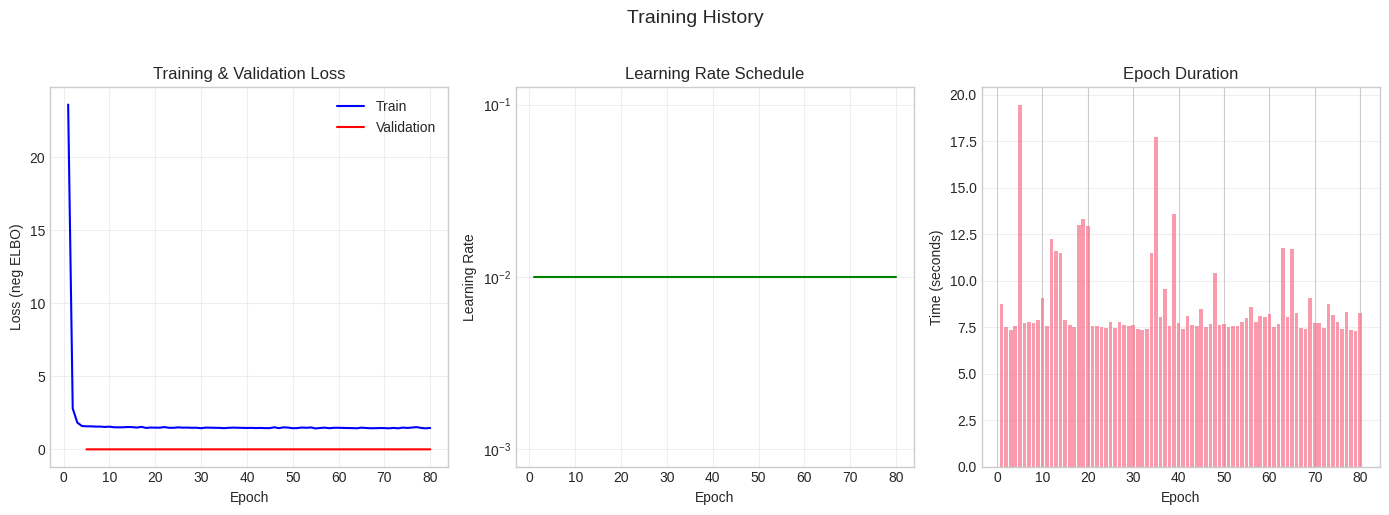

In [15]:
# Plot training history
from src.visualization import plot_training_history

fig = plot_training_history(history.to_dict())
plt.show()

## 5. Make Predictions

In [16]:
from src.inference import Predictor

# Create predictor
predictor = Predictor(
    model,
    scalers=preprocessor.get_scalers(),
    batch_size=1024,
    confidence_levels=[0.5, 0.9, 0.95]
)

# Predict on test data
predictions = predictor.predict(test_data, verbose=True)

print(predictions.summary())

Predicting: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 98/98 [00:00<00:00, 393.72it/s]

Predictions Summary
N predictions: 99,442
Mean range: [11.49, 22.71]
Std range: [9.52, 10.08]
Confidence levels: [0.5, 0.9, 0.95]


## 6. Evaluate Model Performance

In [17]:
from src.evaluation import Evaluator

# Get test observations (using EPA as reference)
test_mask = test_data.source_masks['epa']
y_true = test_data.observations['epa'][test_mask]
y_pred_mean = predictions.mean[test_mask]
y_pred_std = predictions.std[test_mask]

# Evaluate
evaluator = Evaluator(confidence_levels=[0.5, 0.8, 0.9, 0.95])
metrics = evaluator.evaluate(y_true, y_pred_mean, y_pred_std)

print(metrics.summary())

Evaluation Metrics Summary

Point Prediction Metrics:
  rmse: 12.6694
  mse: 160.5146
  mae: 10.3682
  bias: -2.1069
  mape: 83.3010

Probabilistic Metrics:
  nll: 4.0365
  crps: 7.3899
  dss: 6.2350
  sharpness: 9.7520
  pit_deviation: 0.1809
  interval_score_90: 57.2419

Calibration (Coverage @ Level):
  50%: 32.4% (expected: 50.0%)
  80%: 73.0% (expected: 80.0%)
  90%: 75.7% (expected: 90.0%)
  95%: 83.8% (expected: 95.0%)


In [18]:
# Detailed metrics
print("\nAll metrics:")
for name, value in metrics.to_dict().items():
    print(f"  {name}: {value:.4f}")


All metrics:
  rmse: 12.6694
  mse: 160.5146
  mae: 10.3682
  bias: -2.1069
  mape: 83.3010
  nll: 4.0365
  crps: 7.3899
  dss: 6.2350
  sharpness: 9.7520
  pit_deviation: 0.1809
  interval_score_90: 57.2419
  coverage_50: 0.3243
  coverage_80: 0.7297
  coverage_90: 0.7568
  coverage_95: 0.8378
  calibration_error_50: 0.1757
  calibration_error_80: 0.0703
  calibration_error_90: 0.1432
  calibration_error_95: 0.1122


## 7. Visualize Results

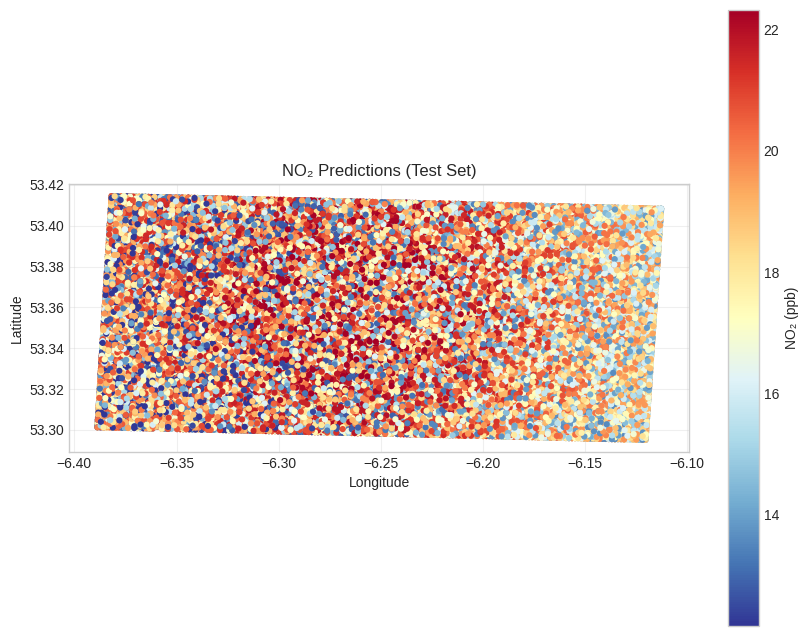

In [19]:
from src.visualization import (
    plot_predictions,
    plot_uncertainty,
    plot_calibration,
    plot_residuals
)

# Spatial prediction map
fig = plot_predictions(
    predictions.coords,
    predictions.mean,
    title="NO₂ Predictions (Test Set)"
)
plt.show()

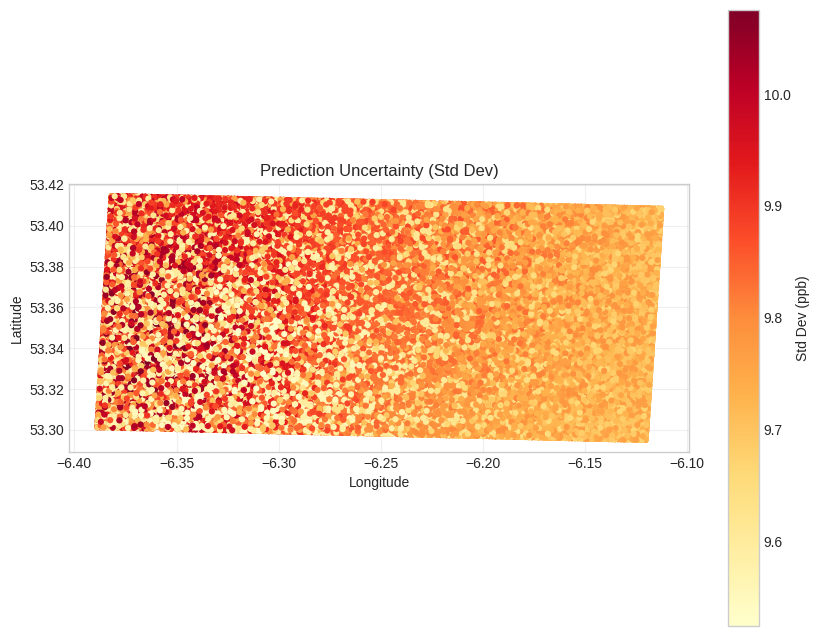

In [20]:
# Uncertainty map
fig = plot_uncertainty(
    predictions.coords,
    predictions.std,
    title="Prediction Uncertainty (Std Dev)"
)
plt.show()

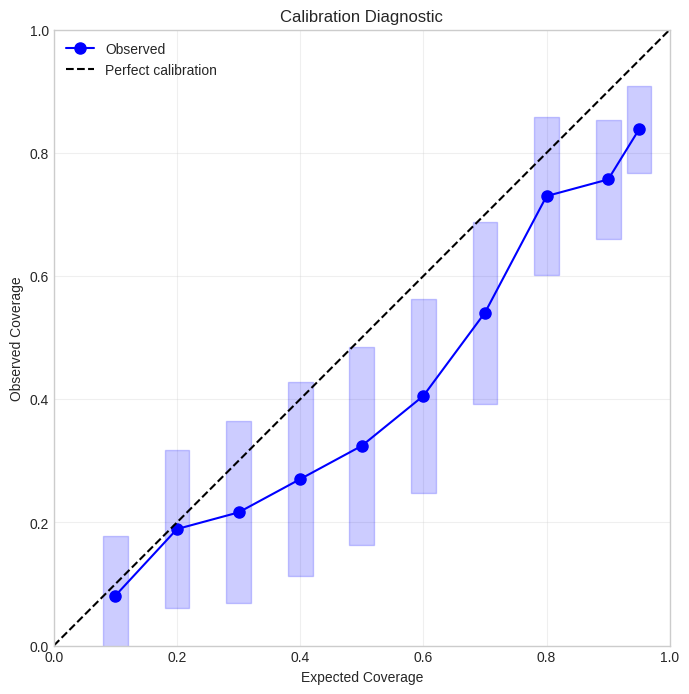

In [21]:
# Calibration plot
fig = plot_calibration(
    y_true, y_pred_mean, y_pred_std,
    title="Calibration Diagnostic"
)
plt.show()

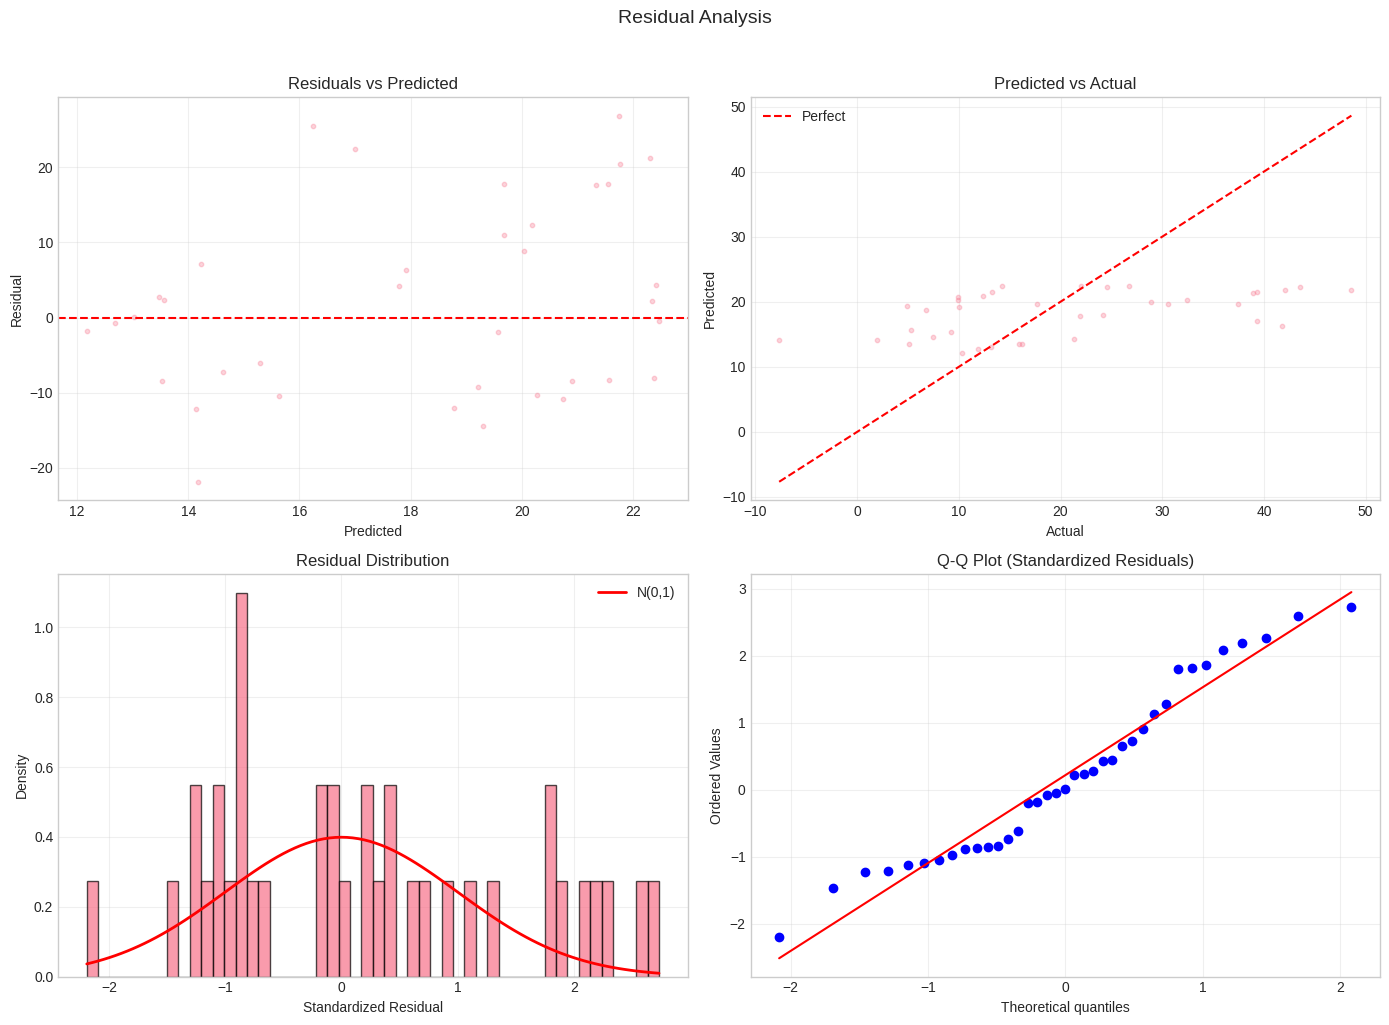

In [22]:
# Residual analysis
fig = plot_residuals(
    y_true, y_pred_mean, y_pred_std,
    title="Residual Analysis"
)
plt.show()

## 8. Inspect Learned Parameters

In [23]:
# Model hyperparameters
params = model.get_hyperparameters()

print("Learned Hyperparameters:")
print("="*50)
for name, value in params.items():
    if isinstance(value, np.ndarray):
        print(f"  {name}: {value}")
    else:
        print(f"  {name}: {value:.4f}")

Learned Hyperparameters:
  mean: 13.552980422973633
  spatial_lengthscale: [[0.6912484 0.6946401]]
  temporal_lengthscale: [[0.3191018]]
  outputscale: 13.506623268127441
  noise_std_epa: 8.924270629882812
  noise_std_satellite: 3.0
  lc_slope: 1.0
  lc_intercept: 0.0
  sat_slope: 1.0
  sat_intercept: 0.0
  n_inducing: 100.0000


In [24]:
# Likelihood parameters (noise and calibration)
print("\nLikelihood Parameters:")
print(model.likelihood)


Likelihood Parameters:
MultiSourceLikelihood(
  noise_std: epa=8.924, satellite=3.000
  lc_calibration: slope=1.000, intercept=0.000
)


## 9. Save Model

In [25]:
# Save trained model
trainer.save('fusiongp_model4.pt')
print("Model saved to fusiongp_model4.pt")

Model saved to fusiongp_model4.pt


## Summary

This notebook demonstrated the complete FusionGP workflow:

1. **Data Loading**: Multi-source observations (EPA, low-cost, satellite)
2. **Preprocessing**: Normalization and train/val/test splitting
3. **Model**: SVGP with spatio-temporal kernel and multi-source likelihood
4. **Training**: ELBO maximization with early stopping
5. **Inference**: Predictions with uncertainty quantification
6. **Evaluation**: Comprehensive metrics including probabilistic scores
7. **Visualization**: Maps, calibration plots, residual diagnostics

Key findings:
- The model successfully fuses heterogeneous observations
- Calibration parameters learn the low-cost sensor bias
- Uncertainty is well-calibrated (coverage matches expected levels)
- Spatial patterns in NO₂ are captured by the GP